In [76]:
import numpy as np, torch

# Neuromancer imports: modeling, loss, logging, system dynamics
import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.dynamics import ode, integrators
from neuromancer.plot import pltCL, pltPhase

# SparseDPC-specific modules: libraries, data, training, utils
from SparseDPC.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.sindy.fx_library import fx_policy_library
from results.utils import *
from
# Set random seed for reproducibility
torch.manual_seed(0)

# Use GPU if available, otherwise fallback to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [99]:
# Ground truth system model
gt_model = psl.nonautonomous.TwoTank()

# Sampling rate
ts = gt_model.params[1]['ts']

# Problem dimensions
nx = gt_model.nx      # number of states
nu = gt_model.nu      # number of control inputs
nref = nx             # reference dimensions equal to state dimensions

# Constraint bounds
umin = 0.
umax = 1.
xmin = 0.
xmax = 1


In [101]:
# Create one fx model per state dimension
fx_models = [fx_library(i, nx=nx, nu=nu, seed=0, device=device) for i in range(nx)]

# Print model structures
for fx in fx_models:
    print(fx)


dx0/dt = -0.000*x0 + 0.027*x1 + -0.041*x0^2 + -0.037*x0*x1 + -0.019*x1^2 + 0.013*u_0 + -0.001*u_1 + 0.040*u_0*u_1 + -0.004*x0*u_0 + 0.013*x1*u_0 + -0.015*x0*u_1 + -0.010*x1*u_1 + -0.048*sqrt(x0) + -0.033*sqrt(x1)

dx1/dt = -0.000*x1 + 0.027*x0 + -0.041*x0^2 + -0.037*x0*x1 + -0.019*x1^2 + 0.013*u_0 + -0.001*u_1 + 0.040*u_0*u_1 + -0.004*x0*u_0 + 0.013*x1*u_0 + -0.015*x0*u_1 + -0.010*x1*u_1 + -0.048*sqrt(x0) + -0.033*sqrt(x1)



In [102]:
import os, glob, torch

run_id = 1
models_dir = f"results/tests/dynamics/run_{run_id}/saved_models"   # change root here

for i, model in enumerate(fx_models):
    pattern = os.path.join(models_dir, f"trained_dynamics_x{i}_*.pth")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No checkpoint for x{i} in {models_dir}")

    ckpt = max(matches, key=os.path.getmtime)
    state_dict = torch.load(ckpt, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"Loaded x{i} from {os.path.basename(ckpt)}")


Loaded x0 from trained_dynamics_x0_20250809_160941.pth
Loaded x1 from trained_dynamics_x1_20250809_160941.pth


In [176]:
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations
import copy
import torch
import torch.nn as nn


run_id = 3
### SPARSE DICTIONARY (SD) MODELS ###
SD_SINDy_policies = [fx_policy_library(nx=nx, nref=1,
                              policy_name=f"u_{k}",
                              seed=1, device=device)
                              for k in range(nu)]


models_dir = f"results/tests/sparse/run_{run_id}/SINDy/saved_models"
for i, model in enumerate(SD_SINDy_policies):
    pattern = os.path.join(models_dir, f"trained_policy_{i}_*.pth")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No checkpoint for u{i} in {models_dir}")

    ckpt = max(matches, key=os.path.getmtime)
    state_dict = torch.load(ckpt, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"Loaded SD-SINDy policy:  u{i} from {os.path.basename(ckpt)}")


def prune_model(model, tol: float = 0.0, *, in_place: bool = False, reinit: bool = False, reinit_std: float = 0.01):
    """
    Prune terms whose |coef| <= tol and remove the corresponding entries from the library.
    Mirrors the 'mask -> active_idx -> slice library + coef' approach in your reference.

    Args:
        model: object with
            - .coef: (n_terms,) or (n_terms, out_dim) tensor / nn.Parameter
            - .library.function_names or .library.functions_names: list[str]
            - optional .library.library: list[callable/objs]
            - optional .library.functions: list[callable]
            - optional .library.shape: tuple
            - optional .library.term_indices: list[...]  (pruned if present)
        tol: threshold; keep a row if any |coef[row]| > tol (for 2D).
        in_place: modify the passed model in place; otherwise returns a deep-copied pruned model.
        reinit: if True, reinitialize the kept coefficients with N(0, reinit_std^2).
        reinit_std: std for reinitialization when reinit=True.

    Returns:
        pruned model (same object if in_place=True, otherwise a deep-copied one).
    """
    m = model if in_place else copy.deepcopy(model)

    with torch.no_grad():
        coef = m.coef
        if coef.ndim == 1:
            mask = torch.abs(coef) > tol                   # (n_terms,)
        elif coef.ndim == 2:
            mask = torch.abs(coef).amax(dim=1) > tol       # (n_terms,)
        else:
            raise ValueError(f"Unsupported coef ndim={coef.ndim}")

        active_idx = torch.nonzero(mask, as_tuple=False).view(-1)
        if active_idx.numel() == 0:
            # keep at least one term to avoid degenerate model
            print("Warning: all terms would be pruned; keeping the largest-magnitude term.")
            if coef.ndim == 1:
                keep_idx = torch.argmax(torch.abs(coef)).view(-1)
            else:
                keep_idx = torch.argmax(torch.abs(coef).amax(dim=1)).view(-1)
            active_idx = keep_idx

        idx = active_idx.tolist()

        # --- slice coefficients
        if reinit:
            new_coef = torch.randn_like(coef[idx, ...]) * reinit_std if coef.ndim == 2 \
                       else torch.randn_like(coef[idx]) * reinit_std
        else:
            new_coef = coef[idx, ...] if coef.ndim == 2 else coef[idx]

        # preserve Parameter-ness and requires_grad
        if isinstance(m.coef, nn.Parameter):
            m.coef = nn.Parameter(new_coef, requires_grad=model.coef.requires_grad)
        else:
            m.coef = new_coef

        # --- resolve names attribute
        names_attr = 'function_names' if hasattr(m.library, 'function_names') else (
                     'functions_names' if hasattr(m.library, 'functions_names') else None)
        if names_attr is not None:
            names = getattr(m.library, names_attr)
            setattr(m.library, names_attr, [names[i] for i in idx])

        # --- prune parallel library structures if present
        if hasattr(m.library, 'library'):
            lib_list = getattr(m.library, 'library')
            setattr(m.library, 'library', [lib_list[i] for i in idx])

        if hasattr(m.library, 'functions'):
            funcs = getattr(m.library, 'functions')
            setattr(m.library, 'functions', [funcs[i] for i in idx])

        if hasattr(m.library, 'term_indices'):
            term_idx = getattr(m.library, 'term_indices')
            setattr(m.library, 'term_indices', [term_idx[i] for i in idx])

        # --- update shape if provided
        if hasattr(m.library, 'shape'):
            old_shape = getattr(m.library, 'shape')
            # assume shape = (n_terms, something)
            setattr(m.library, 'shape', (len(idx), old_shape[1] if len(old_shape) > 1 else 1))

    return m


SD_SINDy_policies = [prune_model(fp) for fp in SD_SINDy_policies]

Loaded SD-SINDy policy:  u0 from trained_policy_0_20250808_150421.pth
Loaded SD-SINDy policy:  u1 from trained_policy_1_20250808_150421.pth


### Online Adaptation

#### Copy the old policy and add noise to the system

In [177]:
copy_SD_SINDy_policies = copy.deepcopy(SD_SINDy_policies)

policy_node_noisy = Node(
            lambda xn, r: torch.cat(
                [torch.clamp(fp(xn, r), umin, umax) for fp in copy_SD_SINDy_policies],
                dim=-1
            ),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )

In [182]:
# white-box ODE model with no-plant model mismatch
gt_model = psl.nonautonomous.TwoTank()
two_tank_noisy = ode.TwoTankParam()                   # ODE system equations implemented in PyTorch
two_tank_noisy.c1 = nn.Parameter(torch.tensor(gt_model.c1+0.05), requires_grad=False)
two_tank_noisy.c2 = nn.Parameter(torch.tensor(gt_model.c2-0.02), requires_grad=False)
gt_model.c1 += 0.05
gt_model.c2 -= 0.02

# integrate continuous time ODE
gt_integrator_noisy = integrators.RK4(two_tank_noisy, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# symbolic system model
gt_integrator_node = Node(gt_integrator_noisy, ['xn', 'u'], ['xn'], name='model')
#noise_node = Node(lambda x: x+ 0.005* torch.rand(x.shape), ['xn_raw'], ['xn'], name='model')
import copy
gt_sindy_policy_noisy = copy.deepcopy(System([policy_node_noisy,
                       gt_integrator_node]))

(<Figure size 2000x1600 with 2 Axes>,
 array([[<Axes: xlabel='Time', ylabel='y'>],
        [<Axes: xlabel='Time', ylabel='u'>]], dtype=object))

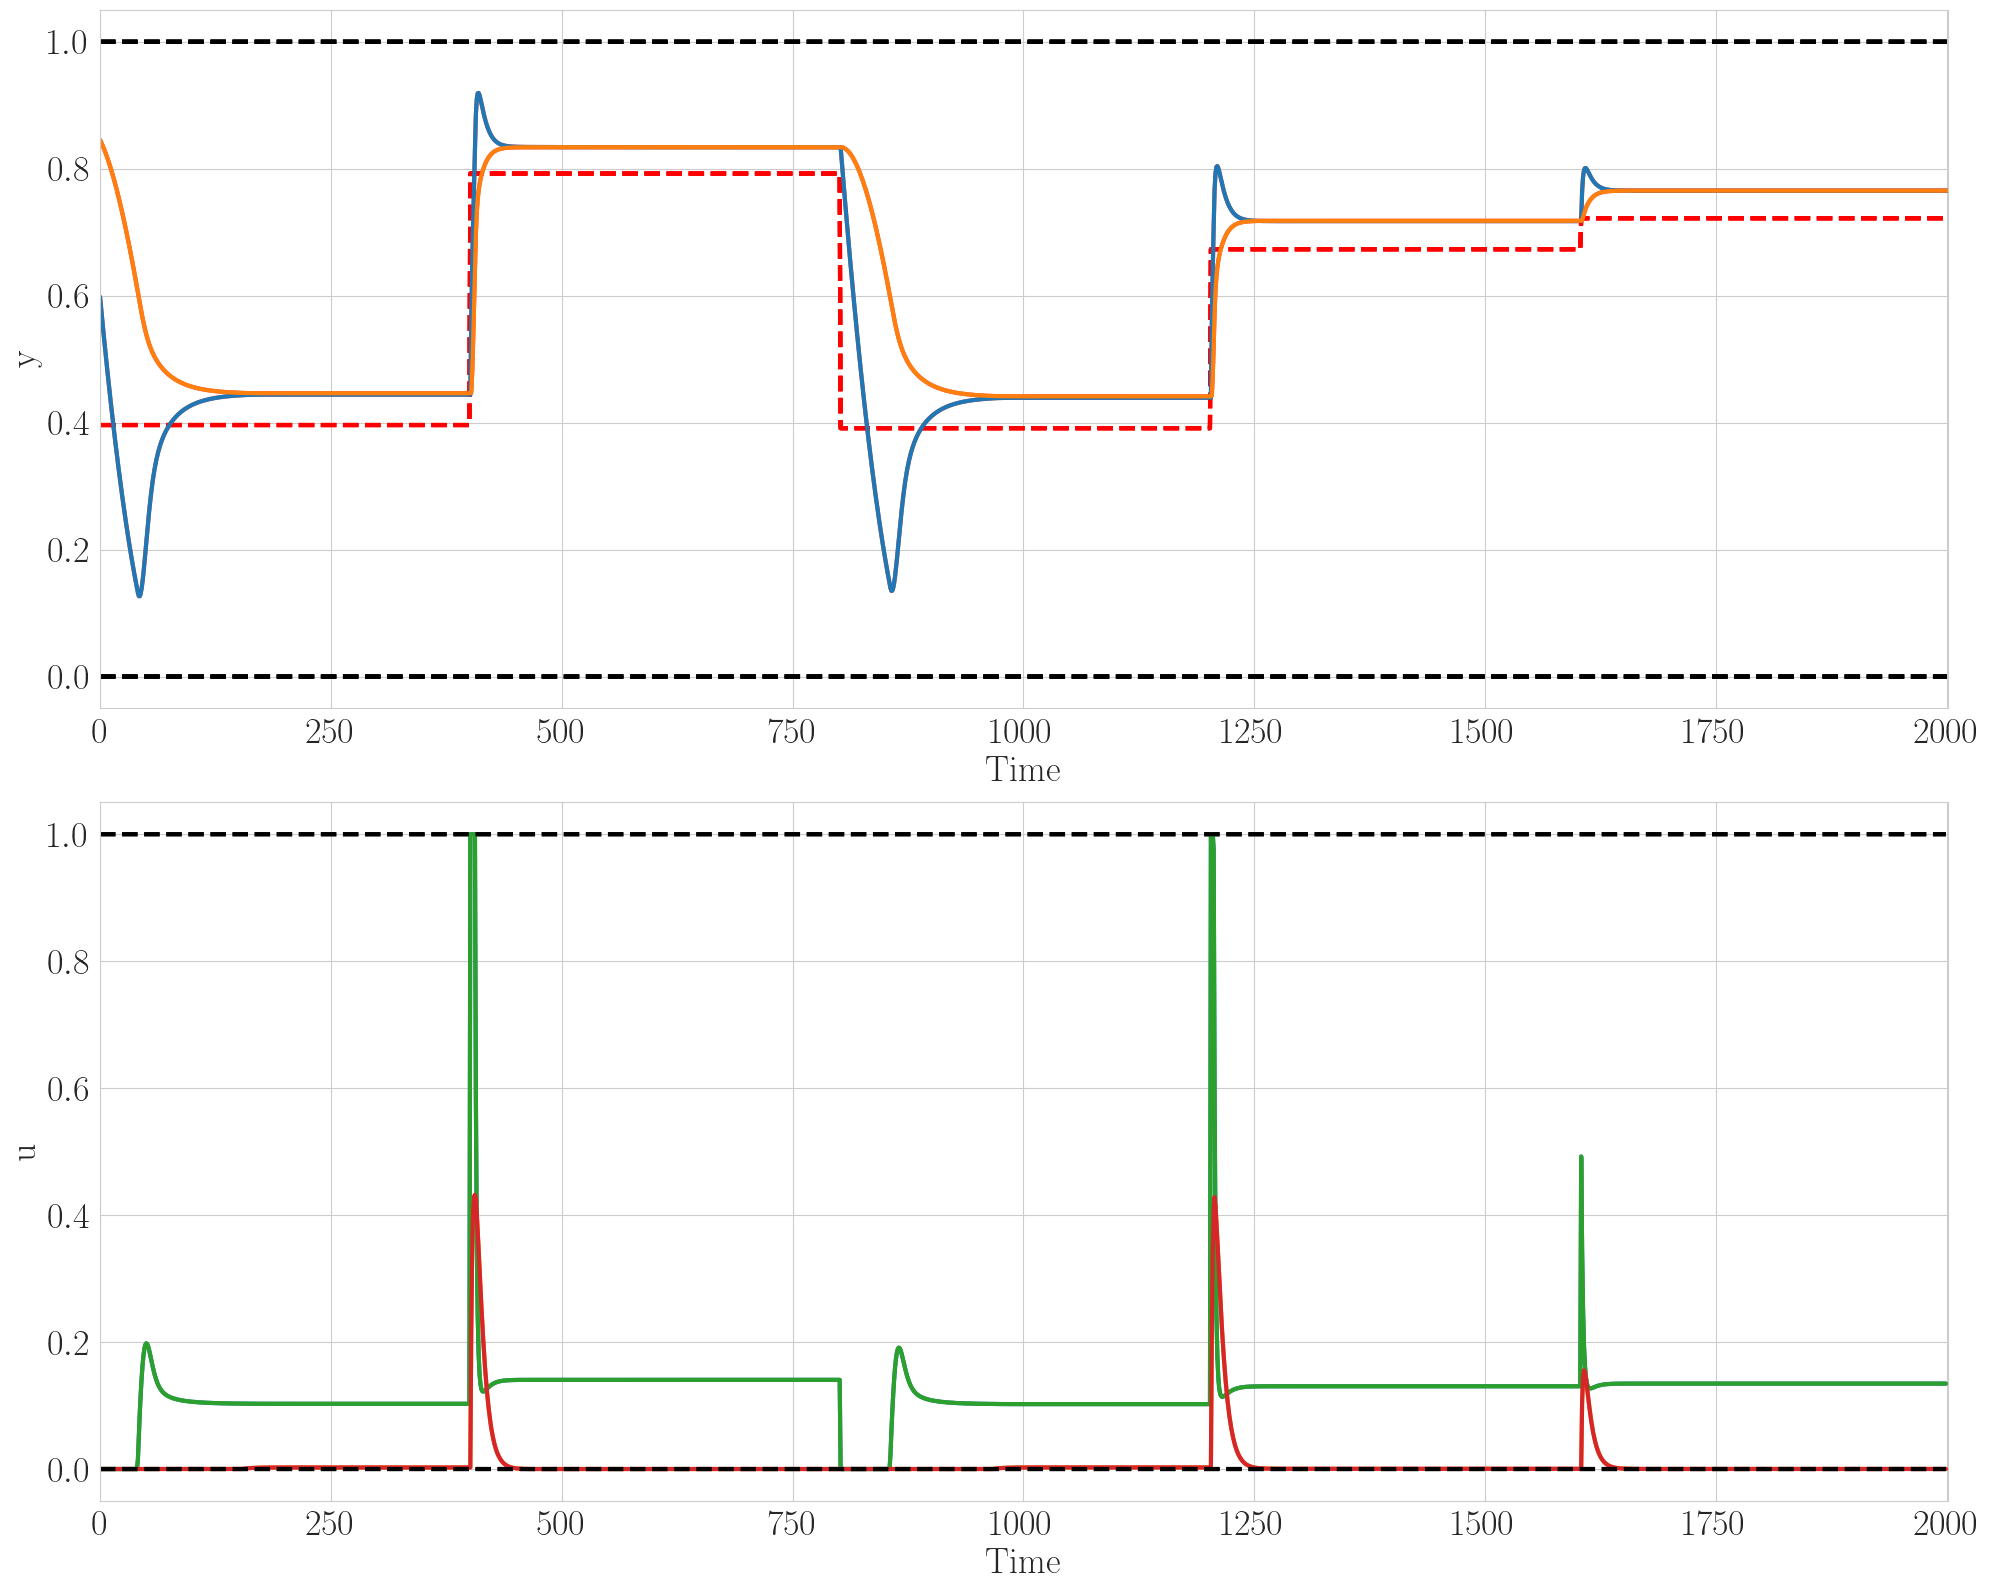

In [183]:
# ---- Setup ----
nsteps = 2000
step_length = 400
N=50
seed = 8
rng = np.random.default_rng(seed)
torch.manual_seed(seed)

# Generate reference signal
np_ref_1 = psl.signals.step(nsteps+2, 1, min=0.2, max=0.8, randsteps=nsteps//step_length, rng=rng)
R_1 = torch.tensor(np_ref_1, dtype=torch.float32).reshape(1, nsteps+2, 1)
torch_ref = torch.cat([R_1, R_1], dim=-1)
xn_test = torch.rand(1, 1, nx, dtype=torch.float32)

# Initial data
data = {
    'xn': xn_test.to(device),
    'x1_n': xn_test[:, :, 0:1].to(device),
    'x2_n': xn_test[:, :, 1:2].to(device),
    'r': torch_ref.to(device)
}


gt_sindy_policy_noisy.nsteps = nsteps
# perform closed-loop simulation
trajectories_before_adaptation = gt_sindy_policy_noisy(data)

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])
# plot closed loop trajectories
pltCL(Y=trajectories_before_adaptation['xn'].detach().reshape(nsteps + 1, nx),
      R=trajectories_before_adaptation['r'].detach().reshape(nsteps + 2, nref),
      U=trajectories_before_adaptation['u'].detach().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)

### Training Loop

In [201]:
from SparseDPC.jacobian.twotank import *

#### Create the symbolic jacobian object

In [202]:
jac_sym  = build_symbolic_jacobian(f_dyn_rows=fx_models,
                                   policies=copy_SD_SINDy_policies,
                                   umin=umin, umax=umax, eps=0.0)  # eps=0 to match clamp exactly

In [206]:
for i in range(nx):
    for j in range(len(SD_SINDy_policies[0].coef) + len(SD_SINDy_policies[1].coef)):
        print(f"Derivative for coefficient {j} in f_{i}(x,u) : ",jac_sym.expr[i,j])

Derivative for coefficient 0 in f_0(x,u) :  (0.0766929462552071 - 0.0765727683901787*u_1)*cos(2*x_0)
Derivative for coefficient 1 in f_0(x,u) :  (0.0766929462552071 - 0.0765727683901787*u_1)*cos(2*x_1)
Derivative for coefficient 2 in f_0(x,u) :  (0.0766929462552071 - 0.0765727683901787*u_1)*cos(2*r_0)
Derivative for coefficient 3 in f_0(x,u) :  (0.0766929462552071 - 0.0765727683901787*u_1)*sin(2*r_0)
Derivative for coefficient 4 in f_0(x,u) :  -0.0765727683901787*u_0*cos(2*x_0)
Derivative for coefficient 5 in f_0(x,u) :  -0.0765727683901787*u_0*cos(2*x_1)
Derivative for coefficient 0 in f_1(x,u) :  0.078864298760891*u_1*cos(2*x_0)
Derivative for coefficient 1 in f_1(x,u) :  0.078864298760891*u_1*cos(2*x_1)
Derivative for coefficient 2 in f_1(x,u) :  0.078864298760891*u_1*cos(2*r_0)
Derivative for coefficient 3 in f_1(x,u) :  0.078864298760891*u_1*sin(2*r_0)
Derivative for coefficient 4 in f_1(x,u) :  0.078864298760891*u_0*cos(2*x_0)
Derivative for coefficient 5 in f_1(x,u) :  0.0788642

#### For faster inference, we create a vectorized version of the jacobian from these derivatives.

In [187]:
import torch
import torch.nn as nn

class VectorizedCoefDerivs(nn.Module):
    """
    Computes d f_i / d a_j for i in {0,1} and j in {0..5}:

      f0:
        d/da0 = (A - B*u1)*cos(2*x0)
        d/da1 = (A - B*u1)*cos(2*x1)
        d/da2 = (A - B*u1)*cos(2*r0)
        d/da3 = (A - B*u1)*sin(2*r0)
        d/da4 = (-B*u0)*cos(2*x0)
        d/da5 = (-B*u0)*cos(2*x1)

      f1:
        d/da0 =  C*u1 *cos(2*x0)
        d/da1 =  C*u1 *cos(2*x1)
        d/da2 =  C*u1 *cos(2*r0)
        d/da3 =  C*u1 *sin(2*r0)
        d/da4 =  C*u0 *cos(2*x0)
        d/da5 =  C*u0 *cos(2*x1)

    Coefficient blocks:
      [a0,a1,a2,a3] belong to policy u0 basis: [cos(2x0), cos(2x1), cos(2r0), sin(2r0)]
      [a4,a5]       belong to policy u1 basis: [cos(2x0), cos(2x1)]

    Input shapes:
      x: (B, 2) with columns [x0, x1]
      u: (B, 2) with columns [u0, u1]  (already clamped if you use clamp)
      r: (B, 2) with columns [r0, r1]  (only r0 used)

    Output:
      J: (B, 2, 6)  where J[:, 0, :] are derivs for f0 and J[:, 1, :] for f1
    """
    def __init__(self,
                 A: float = 0.0766929462552071,
                 B: float = 0.0765727683901787,
                 C: float = 0.078864298760891):
        super().__init__()
        # register as buffers for dtype/device auto-migration
        self.register_buffer("A", torch.tensor(float(A)))
        self.register_buffer("B", torch.tensor(float(B)))
        self.register_buffer("C", torch.tensor(float(C)))
        # sizes for convenience (u0 has 4 coefs, u1 has 2)
        self.register_buffer("psi_sizes", torch.tensor([4, 2], dtype=torch.long))

    def forward(self, x: torch.Tensor, u: torch.Tensor, r: torch.Tensor) -> torch.Tensor:
        if x.dim() != 2 or x.size(-1) != 2:
            raise ValueError("x must be (B, 2)")
        if u.dim() != 2 or u.size(-1) != 2:
            raise ValueError("u must be (B, 2)")
        if r.dim() != 2 or r.size(-1) != 2:
            raise ValueError("r must be (B, 2)")

        # unpack
        x0, x1 = x[:, 0], x[:, 1]
        u0, u1 = u[:, 0], u[:, 1]
        r0     = r[:, 0]

        # shared trig (vectorized)
        c2x0 = torch.cos(2 * x0)
        c2x1 = torch.cos(2 * x1)
        c2r0 = torch.cos(2 * r0)
        s2r0 = torch.sin(2 * r0)

        # factors
        f0_fac     = self.A - self.B * u1      # (B,)
        f0_fac_u0  = -self.B * u0              # (B,)
        f1_fac_u1  =  self.C * u1              # (B,)
        f1_fac_u0  =  self.C * u0              # (B,)

        # f0 derivatives (B, 6)
        df0 = torch.stack([
            f0_fac    * c2x0,   # a0
            f0_fac    * c2x1,   # a1
            f0_fac    * c2r0,   # a2
            f0_fac    * s2r0,   # a3
            f0_fac_u0 * c2x0,   # a4
            f0_fac_u0 * c2x1    # a5
        ], dim=1)

        # f1 derivatives (B, 6)
        df1 = torch.stack([
            f1_fac_u1 * c2x0,   # a0
            f1_fac_u1 * c2x1,   # a1
            f1_fac_u1 * c2r0,   # a2
            f1_fac_u1 * s2r0,   # a3
            f1_fac_u0 * c2x0,   # a4
            f1_fac_u0 * c2x1    # a5
        ], dim=1)

        # stack per-state: (B, 2, 6)
        J = torch.stack([df0, df1], dim=1)
        return J


In [188]:
Jmodule = VectorizedCoefDerivs()


#### Update on new system

In [ ]:
x_trajectory = data['xn'].detach()[:, 0, :].unsqueeze(1)
u_trajectory = torch.zeros([1,1,2])
gamma = 1.
error_hist = []
f_hist = []

In [189]:
for t in range (1,len(data['r'][0])):
    gt_sindy_policy_noisy.nsteps = 1
    next_step_data = gt_sindy_policy_noisy({'xn': x_trajectory[:,-1,:].unsqueeze(0), 'r': data['r'][:, len(x_trajectory[0]), :].unsqueeze(0)})

    x , u,  r = (next_step_data['xn'][:,-1,:].detach(),
                 next_step_data['u'][:,-1,:].detach(),
                 next_step_data['r'][:,-1,:].detach())
    e  = (r - x).reshape(2,1)              # (nx,)

    J_sym = Jmodule(x, u, r).squeeze(0)               # (nx, nA)
    grads = J_sym.T @ e

    # Split and apply to policies
    offset = 0
    with torch.no_grad():
        for pol, n_k in zip(copy_SD_SINDy_policies, jac_sym.psi_sizes):
            pol.coef += gamma * grads[offset:offset+n_k].view_as(pol.coef)
            offset += n_k

    x_trajectory = torch.cat([x_trajectory, next_step_data['xn'].detach()[:,-1:,:]], dim=1)
    u_trajectory = torch.cat([u_trajectory, next_step_data['u'].detach()[:,-1:,:]], dim=1)

    #error_hist.append(e)
    # print(f"Current Error at t= {t}: ",error)

results = {}
results["xn"] = x_trajectory
results["u"] = u_trajectory

In [190]:
# import time
#
# times = []
# for seed in range(20):
#     copy_SD_SINDy_policies = copy.deepcopy(SD_SINDy_policies)
#
#     policy_node_noisy = Node(
#                 lambda xn, r: torch.cat(
#                     [torch.clamp(fp(xn, r), umin, umax) for fp in copy_SD_SINDy_policies],
#                     dim=-1
#                 ),
#                 ['xn', 'r'], ['u'],
#                 name="policy_combined"
#             )
#     gt_sindy_policy_noisy = copy.deepcopy(System([policy_node_noisy,
#                        gt_integrator_node]))
#
#     torch.manual_seed(seed)
#     rng = np.random.default_rng(seed)
#     # generate reference
#     np_refs = psl.signals.step(nsteps+1, 1, min=xmin+0.2, max=xmax-0.2, randsteps=5, rng=rng)
#     R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps+1, 1)
#     torch_ref = torch.cat([R, R], dim=-1)
#
#     data = {'xn': torch.rand(1, 1, nx, dtype=torch.float32),
#             'r': torch_ref}
#
#     x_trajectory = data['xn'].detach()[:, 0, :].unsqueeze(1)
#     u_trajectory = torch.zeros([1,1,2])
#     gamma = 1.
#     error_hist = []
#     f_hist = []
#
#     init_time = time.time()
#     for t in range (1,len(data['r'][0])):
#         gt_sindy_policy_noisy.nsteps = 1
#         next_step_data = gt_sindy_policy_noisy({'xn': x_trajectory[:,-1,:].unsqueeze(0), 'r': data['r'][:, len(x_trajectory[0]), :].unsqueeze(0)})
#
#         x , u,  r = (next_step_data['xn'][:,-1,:].detach(),
#                  next_step_data['u'][:,-1,:].detach(),
#                  next_step_data['r'][:,-1,:].detach())
#         e  = (r - x).reshape(2,1)              # (nx,)
#
#         J_sym = Jmodule(x, u, r).squeeze(0)               # (nx, nA)
#         grads = J_sym.T @ e
#
#         # Split and apply to policies
#         offset = 0
#         n_0, n_1 = jac_sym.psi_sizes
#         with torch.no_grad():
#             copy_SD_SINDy_policies[0].coef += gamma * grads[0:n_0]
#             copy_SD_SINDy_policies[1].coef += gamma * grads[n_0:n_0+n_1]
#             # for pol, n_k in zip(copy_SD_SINDy_policies, jac_sym.psi_sizes):
#             #     pol.coef += gamma * grads[offset:offset+n_k].view_as(pol.coef)
#             #     offset += n_k
#
#         x_trajectory = torch.cat([x_trajectory, next_step_data['xn'].detach()[:,-1:,:]], dim=1)
#         u_trajectory = torch.cat([u_trajectory, next_step_data['u'].detach()[:,-1:,:]], dim=1)
#         # Track error and loss history
#         #error_hist.append((r.detach() - x.detach()).cpu().numpy().ravel())
#         #f_hist.append(loss.item())
#
#     # Pack results (same keys as before, plus histories)
#     # results = {
#     #     "xn": x_trajectory,
#     #     "u" : u_trajectory,
#     #     "error_hist": error_hist,
#     #     "f_hist": f_hist,
#     # }
#     end_time = time.time()
#     times.append(end_time - init_time)
#
# print("total time: ", np.sum(times), " average time: " , np.mean(times))


In [192]:
# Get best results using adaptive horizon MPC

from results.utils import mpc_solve_adaptive_horizon
N=50
MPC_trajectories = mpc_solve_adaptive_horizon(data, gt_model, N_max=N, N_min=2, nsim=nsteps, step_length=step_length, Ru=0.0, Rdu=0.01)

In [193]:
Y_list = [
    trajectories_before_adaptation['xn'].detach().cpu().reshape(nsteps + 1, nx),
    x_trajectory[:,:-1,:].detach().cpu().reshape(nsteps + 1, nx),
    MPC_trajectories['xn'].reshape(nsteps + 1, nx)
]

U_list = [
    trajectories_before_adaptation['u'].detach().cpu().reshape(nsteps, nu),
    u_trajectory[:,:-2,:].reshape(nsteps, nu),
    MPC_trajectories['u'].reshape(nsteps, nu)
]

R = trajectories_before_adaptation['r'].detach().cpu()[:,:nsteps+1].reshape(nsteps + 1, nref)

# Constraints
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Ymin = xmin * np.ones([nsteps + 1, nx])
Ymax = xmax * np.ones([nsteps + 1, nx])




In [198]:
controller_labels = ["Before Adaptation", "Online Adaptation", "MPC"]
style_map = {
    "Before Adaptation": ("-", 1.1, 0.5, "darkorange"),
    "Online Adaptation": ("-", 1.1, 0.8, "royalblue"),
    "MPC": ("-", 1.1, 0.5, "darkgreen")
}

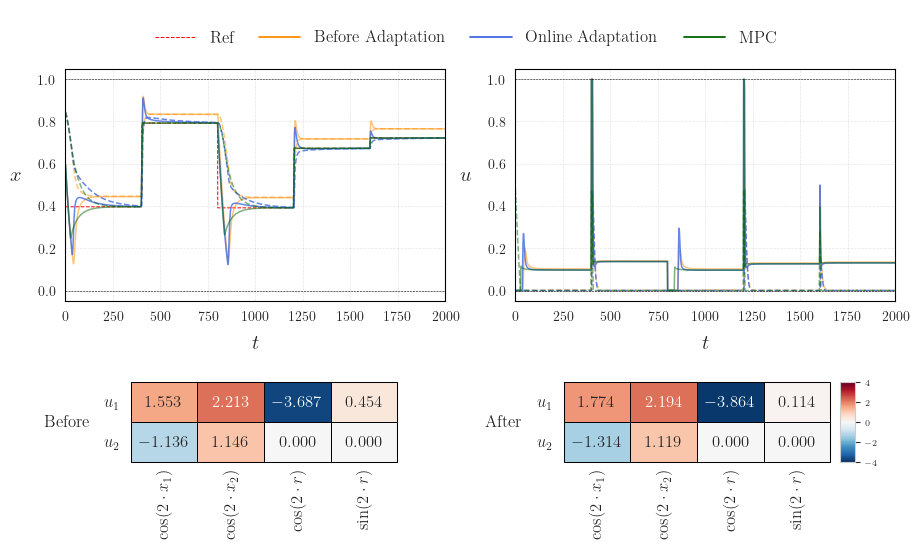

In [200]:
combined_controller_and_two_policy_heatmaps(
    Y_list=Y_list,
    U_list=U_list,
    controller_labels=controller_labels,
    fx_policy_SINDy=SD_SINDy_policies,
    fx_policy_WB=copy_SD_SINDy_policies,
    fx_policy_labels=[r"${u}_1$", r"${u}_2$"],
    R=R,
    style_map=style_map,
    TS_FIG_WIDTH=10,
    TS_FIG_HEIGHT=10,
    CELL_SIZE=0.7,
    FONT_SIZE_COEFS=12,
    FONT_SIZE_COEFS_LABELS=12,
    xmin=0.0, xmax=1.0,
    umin=0.0, umax=1.0,
    title=None,
    save_name="results/TwoTank_Adaptation_Jacobian.pdf"
)